# import package

In [3]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [1]:
import sys


In [2]:
#sys.path.append('/content/drive/MyDrive/Research/0-Xiayin_research/4_GeoCP_with_geosimilarity/GeoConformal')
sys.path.append('/content/drive/MyDrive/Research/0_GeoCP_with_geosimilarity/GeoConformal')

import GeoConformalSpatialRegression

In [4]:
import GeoSIMCPzhao

In [6]:
!pip install xgboost geopandas geoplot contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 91.2 MB/s eta 0:00:00


In [5]:
import xgboost as xgb
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geoplot as gplt
import geoplot.crs as gcrs
from sklearn.model_selection import train_test_split
import contextily as cx


In [6]:
!pip install quantile_forest mapclassify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 10.8 MB/s eta 0:00:00


# Load data

In [11]:
# # # ## housing price

data = pd.read_csv('/content/drive/MyDrive/Research/0_GeoCP_with_geosimilarity//data/seattle_sample_3k.csv')
data = gpd.GeoDataFrame(data, crs="EPSG:32610", geometry=gpd.points_from_xy(x=data.UTM_X, y=data.UTM_Y))
data = data.to_crs(4326)

data['lat'] = data['geometry'].get_coordinates()['x']
data['lon'] = data['geometry'].get_coordinates()['y']

data['price'] = np.power(10, data['log_price']) / 10000

y = data.price
X_aspatial = data[['bathrooms', 'sqft_living', 'sqft_lot', 'grade', 'condition', 'waterfront', 'view', 'age']]
X_spatial = data[['bathrooms', 'sqft_living', 'sqft_lot', 'grade', 'condition', 'waterfront', 'view', 'age', 'UTM_X', 'UTM_Y']]
loc = data[['lat','lon']]

In [9]:
# # US life

data = pd.read_csv('/content/drive/MyDrive/Research/0_GeoCP_with_geosimilarity//data//us_life_expectancy.csv')
data = data.dropna(subset=['ratio', 'Diversity', 'Asianalon', 'NativeHaw', 'TwoorMor', 'Hispanico', 'Whitealon'])

# Remove rows where 'le_racea_4' is 0
data = data[data['le_racea_4'] != 0]

features = data[['ratio', 'Diversity', 'Asianalon', 'NativeHaw', 'TwoorMor', 'Hispanico', 'Whitealon']]
loc = data[['lon', 'lat']]

y = data['le_racea_4']
X_aspatial = data[['ratio', 'Diversity', 'Asianalon', 'NativeHaw', 'TwoorMor', 'Hispanico', 'Whitealon']]
X_spatial = data[['ratio', 'Diversity', 'Asianalon', 'NativeHaw', 'TwoorMor', 'Hispanico', 'Whitealon', 'lat','lon']]

In [10]:
# # ## China PM2.5
data = pd.read_csv('/content/drive/MyDrive/Research/0_GeoCP_with_geosimilarity//data//china_sites_2018_05_PM2.5_all.csv')

features = data[['dem', 'sp', 'tp', 'blh', 'r', 'aod_sat', 'ndvi']]
loc = data[['lon', 'lat']]

y = data['PM2.5']
X_aspatial = data[['dem', 'sp', 'tp', 'blh', 'r', 'aod_sat', 'ndvi']]
X_spatial = data[['dem', 'sp', 'tp', 'blh', 'r', 'aod_sat', 'ndvi','lon', 'lat']]


In [12]:
data

,Unnamed: 0,bathrooms,sqft_living,sqft_lot,grade,condition,waterfront,view,age,UTM_X,UTM_Y,log_price,geometry,lat,lon,price
0,0,3.00,2660,4600,8,3,0,0,109,552217.557035,5.274945e+06,6.091315,POINT (-122.305 47.6258),-122.305,47.6258,123.4000
1,1,2.25,2530,8736,7,4,0,0,57,565692.484331,5.272758e+06,5.790988,POINT (-122.126 47.6049),-122.126,47.6049,61.8000
2,2,2.00,1390,13464,7,4,0,0,28,562451.661509,5.245291e+06,5.315130,POINT (-122.173 47.3581),-122.173,47.3581,20.6600
3,3,1.00,940,4264,7,5,0,0,66,546816.935618,5.264407e+06,5.619093,POINT (-122.378 47.5314),-122.378,47.5314,41.6000
4,4,2.25,2070,7225,8,3,0,0,36,564343.195352,5.244978e+06,5.477121,POINT (-122.148 47.3551),-122.148,47.3551,30.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2995,1.50,1290,8366,7,3,0,0,58,551377.991268,5.259321e+06,5.380211,POINT (-122.318 47.4853),-122.318,47.4853,24.0000
2996,2996,1.50,1490,12186,7,4,0,0,65,550796.231636,5.291393e+06,5.566895,POINT (-122.322 47.7739),-122.322,47.7739,36.8888
2997,2997,1.50,1510,16800,8,5,0,0,59,549619.278143,5.288838e+06,5.618048,POINT (-122.338 47.751),-122.338,47.7510,41.5000
2998,2998,2.00,1640,3021,7,3,0,2,56,548198.517745,5.279378e+06,5.732394,POINT (-122.358 47.666),-122.358,47.6660,54.0000


# train prediction model

In [13]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import xgboost as xgb

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

def get_model(model_name='xgboost', param_grid=None, do_gridsearch=False):
    if model_name == 'xgboost':
        base_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
        default_grid = {
            'n_estimators': [100, 300, 500],
            'max_depth': [3, 5],
            'min_child_weight': [1.0, 5.0],
            'colsample_bytree': [0.8, 1.0],
        }
    elif model_name == 'random_forest':
        base_model = RandomForestRegressor(random_state=42)
        default_grid = {
            'n_estimators': [100, 300],
            'max_depth': [None, 10],
        }
    elif model_name == 'svr':
        base_model = SVR()
        default_grid = {
            'C': [1.0, 10.0],
            'gamma': ['scale', 'auto']
        }
    elif model_name == 'mlp':
        base_model = MLPRegressor(random_state=42, max_iter=1000)
        default_grid = {
            'hidden_layer_sizes': [(100,), (50, 50)],
            'alpha': [0.0001, 0.001]
        }
    else:
        raise ValueError(f"Unsupported model: {model_name}")

    if do_gridsearch:
        search = GridSearchCV(base_model, param_grid or default_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
        return search
    else:
        return base_model

def train_and_evaluate_model(X_train, X_val, X_test, y_train, y_val, y_test, model_name='random_forest', do_gridsearch=False):
    model = get_model(model_name, do_gridsearch=do_gridsearch)
    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    rmse_val, mae_val, r2_val = regression_metrics(y_val, y_val_pred)
    rmse_test, mae_test, r2_test = regression_metrics(y_test, y_test_pred)

    print(f"[Validation] RMSE: {rmse_val:.3f}, MAE: {mae_val:.3f}, R²: {r2_val:.3f}")
    print(f"[Test]      RMSE: {rmse_test:.3f}, MAE: {mae_test:.3f}, R²: {r2_test:.3f}")

    return model, y_val_pred, y_test_pred


In [ ]:
# 变量名与原始保持一致
X_aspatial_train, X_apsatial_temp, X_spatial_train, X_spatial_temp, y_train, y_temp, loc_train, loc_temp = train_test_split(
    X_aspatial, X_spatial, y, loc, train_size=0.8, random_state=42)
X_aspatial_val, X_aspatial_test, X_spatial_val, X_spatial_test, y_val, y_test, loc_val, loc_test = train_test_split(
    X_apsatial_temp, X_spatial_temp, y_temp, loc_temp, train_size=0.5, random_state=42)

model_spatial, y_val_pred, y_test_pred = train_and_evaluate_model(
    X_spatial_train, X_spatial_val, X_spatial_test,
    y_train, y_val, y_test,
    model_name='random_forest',
    do_gridsearch=True
)


[Validation] RMSE: 0.829, MAE: 0.534, R²: 0.736
[Test]      RMSE: 1.032, MAE: 0.674, R²: 0.607


# RUN all UQ model


In [ ]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'Arial'

def run_all_uq_models(predict_models: dict, uq_model_names: list, data_dict: dict):
    results = []

    for model_name, model in predict_models.items():
        for uq_name in uq_model_names:
            print(f"Running UQ model [{uq_name}] with predictor [{model_name}]...")
            start_time = time.time()

            if uq_name == 'geocp':
                from GeoConformalSpatialRegression import GeoConformalSpatialRegression
                def interval_score(y_true, lower, upper, alpha=0.1, epsilon=1e-6):
                    width = np.maximum(upper - lower, epsilon)
                    below = (lower - y_true) * (y_true < lower)
                    above = (y_true - upper) * (y_true > upper)
                    return width + (2 / alpha) * (below + above)
                bandwidth_list = np.linspace(0.1, 5.0, 20)
                coverage_list, uncertainty_list, interval_score_list = [], [], []
                for bw in bandwidth_list:
                    model_uq = GeoConformalSpatialRegression(
                        predict_f=model.predict,
                        miscoverage_level=0.1,
                        bandwidth=bw,
                        coord_calib=data_dict['loc_val'].values,
                        coord_test=data_dict['loc_test'].values,
                        X_calib=data_dict['X_spatial_val'],
                        y_calib=data_dict['y_val'],
                        X_test=data_dict['X_spatial_test'],
                        y_test=data_dict['y_test']
                    )
                    result = model_uq.analyze()
                    coverage_list.append(result.coverage_probability)
                    unc = np.array(result.geo_uncertainty)
                    unc = unc[~np.isnan(unc)]
                    uncertainty_list.append(np.mean(unc) if len(unc) > 0 else np.nan)
                    score = interval_score(data_dict['y_test'], np.array(result.lower_bound), np.array(result.upper_bound))
                    score = score[~np.isnan(score)]
                    interval_score_list.append(np.mean(score) if len(score) > 0 else np.nan)
                best_idx = np.where(np.array(coverage_list) >= 0.9, interval_score_list, np.inf).argmin()
                duration = time.time() - start_time
                fig, ax1 = plt.subplots(figsize=(10, 6))
                ax1.plot(bandwidth_list, coverage_list, 'b-', label='Coverage')
                ax1.text(bandwidth_list[best_idx], coverage_list[best_idx], f"bw={bandwidth_list[best_idx]:.2f}", color='black')
                ax1.set_ylabel('Coverage', color='b')
                ax2 = ax1.twinx()
                ax2.plot(bandwidth_list, uncertainty_list, 'r-', label='Uncertainty')
                ax2.set_ylabel('Uncertainty', color='r')
                ax3 = ax1.twinx()
                ax3.spines['right'].set_position(('axes', 1.1))
                ax3.plot(bandwidth_list, interval_score_list, 'g--', label='Interval Score')
                ax3.set_ylabel('Interval Score', color='g')
                ax1.set_xlabel('Bandwidth')
                plt.title(f'GeoCP Tuning - {model_name}')
                plt.tight_layout()
                plt.savefig(f'/content/drive/MyDrive/Research/0_GeoCP_with_geosimilarity//GeoCP_{model_name}.pdf')
                plt.close()
                results.append({
                    'predict_model': model_name,
                    'uq_model': 'GeoCP',
                    'coverage': coverage_list[best_idx],
                    'interval_score': interval_score_list[best_idx],
                    'uncertainty': uncertainty_list[best_idx],
                    'param_1': f"bw={bandwidth_list[best_idx]:.3f}",
                    'param_2': None,
                    'uq_time_sec': duration
                })

            elif uq_name in ['geosimcp', 'geosimcp_zhao']:
                if uq_name == 'geosimcp':
                    from GeoSIMCP import GeoSIMConformalSpatialRegression as SIMModel
                    pdf_name = f'/content/drive/MyDrive/Research/0_GeoCP_with_geosimilarity//GeoSIMCP_{model_name}.pdf'
                else:
                    from GeoSIMCPzhao import GeoSIMCPzhao as SIMModel
                    pdf_name = f'/content/drive/MyDrive/Research/0_GeoCP_with_geosimilarity//GeoSIMCP_ZHAO_{model_name}.pdf'
                def interval_score(y_true, lower, upper, alpha=0.1):
                    width = upper - lower
                    below = (lower - y_true) * (y_true < lower)
                    above = (y_true - upper) * (y_true > upper)
                    return width + (2 / alpha) * (below + above)
                bandwidth_list = np.linspace(0.1, 5.0, 20)
                lambda_list = np.linspace(0.0, 1.0, 20)
                coverage_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
                score_grid = np.zeros_like(coverage_grid)
                unc_grid = np.zeros_like(coverage_grid)
                for i, bw in enumerate(bandwidth_list):
                    for j, lam in enumerate(lambda_list):
                        model_uq = SIMModel(
                            predict_f=model.predict,
                            miscoverage_level=0.1,
                            bandwidth=bw,
                            coord_calib=data_dict['loc_val'].values,
                            coord_test=data_dict['loc_test'].values,
                            X_calib=data_dict['X_spatial_val'],
                            y_calib=data_dict['y_val'],
                            X_test=data_dict['X_spatial_test'],
                            y_test=data_dict['y_test'],
                            X_calib_weight=data_dict['X_aspatial_val'],
                            X_test_weight=data_dict['X_aspatial_test'],
                            lambda_weight=lam
                        )
                        result = model_uq.analyze()
                        coverage_grid[i, j] = result.coverage_probability
                        unc = np.array(result.geo_uncertainty) if hasattr(result, 'geo_uncertainty') else None
                        if unc is not None:
                            unc = unc[~np.isnan(unc)]
                            unc_grid[i, j] = np.mean(unc) if len(unc) > 0 else np.nan
                        score = interval_score(data_dict['y_test'], np.array(result.lower_bound), np.array(result.upper_bound))
                        score_grid[i, j] = np.mean(score)
                mask = coverage_grid >= 0.9
                score_masked = np.where(mask, score_grid, np.inf)
                idx = np.unravel_index(np.argmin(score_masked), score_masked.shape)
                duration = time.time() - start_time
                extent = [lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]]
                fig, axs = plt.subplots(1, 3, figsize=(18, 5))
                im1 = axs[0].imshow(coverage_grid, origin='lower', aspect='auto', cmap='YlGnBu', extent=extent)
                axs[0].set_title('Coverage')
                axs[0].scatter(lambda_list[idx[1]], bandwidth_list[idx[0]], color='black', marker='x')
                axs[0].text(lambda_list[idx[1]], bandwidth_list[idx[0]], f"λ={lambda_list[idx[1]]:.2f}, bw={bandwidth_list[idx[0]]:.2f}", color='black')
                im2 = axs[1].imshow(unc_grid, origin='lower', aspect='auto', cmap='YlOrBr', extent=extent)
                axs[1].set_title('Uncertainty')
                axs[1].scatter(lambda_list[idx[1]], bandwidth_list[idx[0]], color='black', marker='x')
                im3 = axs[2].imshow(score_masked, origin='lower', aspect='auto', cmap='BuGn', extent=extent)
                axs[2].set_title('Interval Score')
                axs[2].scatter(lambda_list[idx[1]], bandwidth_list[idx[0]], color='black', marker='x')
                for ax in axs:
                    ax.set_xlabel('Lambda')
                    ax.set_ylabel('Bandwidth')
                plt.tight_layout()
                plt.savefig(pdf_name)
                plt.close()
                results.append({
                    'predict_model': model_name,
                    'uq_model': 'GeoSIMCP' if uq_name == 'geosimcp' else 'GeoSIMCP_ZHAO',
                    'coverage': coverage_grid[idx],
                    'interval_score': score_grid[idx],
                    'uncertainty': unc_grid[idx],
                    'param_1': f"bw={bandwidth_list[idx[0]]:.3f}",
                    'param_2': f"λ={lambda_list[idx[1]]:.3f}",
                    'uq_time_sec': duration
                })

            elif uq_name == 'lscp':
                import LSCP
                def interval_score(y_true, lower, upper, alpha=0.1):
                    width = upper - lower
                    below = (lower - y_true) * (y_true < lower)
                    above = (y_true - upper) * (y_true > upper)
                    return width + (2 / alpha) * (below + above)
                k_list = [5, 8, 10, 15, 20]
                coverage_list, uncertainty_list, interval_score_list = [], [], []
                for k in k_list:
                    model_uq = LSCP.LSCP(
                        predict_f=model.predict,
                        miscoverage_level=0.1,
                        k=k,
                        coord_calib=data_dict['loc_val'].values,
                        coord_test=data_dict['loc_test'].values,
                        x_calib=data_dict['X_spatial_val'],
                        y_calib=data_dict['y_val'],
                        x_test=data_dict['X_spatial_test'],
                        y_test=data_dict['y_test']
                    )
                    result = model_uq.analyze()
                    coverage_list.append(result.coverage_probability)
                    unc = np.array(result.geo_uncertainty / 2)
                    unc = unc[~np.isnan(unc)]
                    uncertainty_list.append(np.mean(unc) if len(unc) > 0 else np.nan)
                    score = interval_score(data_dict['y_test'], np.array(result.lower_bound), np.array(result.upper_bound))
                    score = score[~np.isnan(score)]
                    interval_score_list.append(np.mean(score) if len(score) > 0 else np.nan)
                best_idx = np.where(np.array(coverage_list) >= 0.9, interval_score_list, np.inf).argmin()
                duration = time.time() - start_time
                fig, ax1 = plt.subplots(figsize=(10, 6))
                ax1.plot(k_list, coverage_list, 'b-', label='Coverage')
               # ax1.text(bandwidth_list[best_idx], coverage_list[best_idx], f"bw={bandwidth_list[best_idx]:.2f}", color='black')
                ax1.text(k_list[best_idx], coverage_list[best_idx], f"k={k_list[best_idx]}", color='black')
                ax1.set_ylabel('Coverage', color='b')
                ax2 = ax1.twinx()
                ax2.plot(k_list, uncertainty_list, 'r-', label='Uncertainty')
                ax2.set_ylabel('Uncertainty', color='r')
                ax3 = ax1.twinx()
                ax3.spines['right'].set_position(('axes', 1.1))
                ax3.plot(k_list, interval_score_list, 'g--', label='Interval Score')
                ax3.set_ylabel('Interval Score', color='g')
                ax1.axvline(k_list[best_idx], color='black', linestyle='--')
                ax1.set_xlabel('k')
                plt.title(f'LSCP Tuning - {model_name}')
                plt.tight_layout()
                plt.savefig(f'/content/drive/MyDrive/Research/0_GeoCP_with_geosimilarity//LSCP_{model_name}.pdf')
                plt.close()
                results.append({
                    'predict_model': model_name,
                    'uq_model': 'LSCP',
                    'coverage': coverage_list[best_idx],
                    'interval_score': interval_score_list[best_idx],
                    'uncertainty': uncertainty_list[best_idx],
                    'param_1': f"k={k_list[best_idx]}",
                    'param_2': None,
                    'uq_time_sec': duration
                })

    results_df = pd.DataFrame(results)
    return results_df


In [ ]:

# 变量名与原始保持一致
X_aspatial_train, X_apsatial_temp, X_spatial_train, X_spatial_temp, y_train, y_temp, loc_train, loc_temp = train_test_split(
    X_aspatial, X_spatial, y, loc, train_size=0.8, random_state=42)
X_aspatial_val, X_aspatial_test, X_spatial_val, X_spatial_test, y_val, y_test, loc_val, loc_test = train_test_split(
    X_apsatial_temp, X_spatial_temp, y_temp, loc_temp, train_size=0.5, random_state=42)


# 构建多个预测模型（用相同数据训练，供对比用）
models = {}
for name in ['xgboost', 'random_forest', 'svr', 'mlp']:
    print(f"Training model: {name}")
    m, _, _ = train_and_evaluate_model(
        X_spatial_train, X_spatial_val, X_spatial_test,
        y_train, y_val, y_test,
        model_name=name,
        do_gridsearch=True  # 启用自动调参
    )
    models[name] = m

# 构建数据字典供 run_all_uq_models 使用
data_dict = {
    'X_spatial_val': X_spatial_val,
    'X_spatial_test': X_spatial_test,
    'X_aspatial_val': X_aspatial_val,
    'X_aspatial_test': X_aspatial_test,
    'y_val': y_val,
    'y_test': y_test,
    'loc_val': loc_val,
    'loc_test': loc_test
}

# 调用统一评估函数
results_df = run_all_uq_models(
    predict_models=models,
  #  uq_model_names=['geocp', 'geosimcp', 'geosimcp_zhao'],
    uq_model_names=['lscp'],
    data_dict=data_dict
)

display(results_df)


Training model: xgboost
[Validation] RMSE: 0.872, MAE: 0.590, R²: 0.708
[Test]      RMSE: 1.139, MAE: 0.736, R²: 0.522
Training model: random_forest
[Validation] RMSE: 0.829, MAE: 0.534, R²: 0.736
[Test]      RMSE: 1.032, MAE: 0.674, R²: 0.607
Training model: svr
[Validation] RMSE: 0.998, MAE: 0.660, R²: 0.617
[Test]      RMSE: 1.221, MAE: 0.789, R²: 0.451
Training model: mlp
[Validation] RMSE: 1.413, MAE: 1.055, R²: 0.232
[Test]      RMSE: 1.540, MAE: 1.052, R²: 0.126
Running UQ model [lscp] with predictor [xgboost]...
🚀 Start optimizing Beta for 229 points...


Optimizing Beta (serial):  44%|████▎     | 100/229 [02:34<02:36,  1.22s/it]

Progress: 100/229 | Speed: 0.65 pts/s | ETA: 3.33 min


Optimizing Beta (serial):  87%|████████▋ | 200/229 [05:10<01:00,  2.09s/it]

Progress: 200/229 | Speed: 0.64 pts/s | ETA: 0.75 min


...

Predicting Bounds (serial):  89%|████████▉ | 204/229 [00:06<00:00, 34.07it/s]

Progress: 200/229 | Speed: 33.96 pts/s | ETA: 0.01 min


Predicting Bounds (serial): 100%|██████████| 229/229 [00:06<00:00, 33.95it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(


Progress: 229/229 | Speed: 33.95 pts/s | ETA: 0.00 min
✅ Prediction completed in 0.11 minutes.


,predict_model,uq_model,coverage,interval_score,uncertainty,param_1,param_2,uq_time_sec
0,xgboost,LSCP,0.703057,6.994390,1.181004,k=5,None,1724.252203
1,random_forest,LSCP,0.724891,6.193969,1.047567,k=5,None,1731.590089
2,svr,LSCP,0.759825,7.062954,1.351578,k=5,None,1905.579975
3,mlp,LSCP,0.820961,7.553056,1.758200,k=5,None,1818.280860


# GeoCP

In [ ]:
## GeoCP
from GeoConformalSpatialRegression import GeoConformalSpatialRegression

geocp_spatial = GeoConformalSpatialRegression(predict_f=model_spatial.predict, nonconformity_score_f=None, miscoverage_level=0.1, bandwidth=0.15, coord_calib=loc_val.values, coord_test=loc_test.values, X_calib=X_spatial_val, y_calib=y_val, X_test=X_spatial_test, y_test=y_test)

In [ ]:
results = geocp_spatial.analyze()


/content/drive/MyDrive/Research/0-Xiayin_research/4_GeoCP_with_geosimilarity/GeoConformal/GeoConformalSpatialRegression.py:131: RuntimeWarning: invalid value encountered in divide
  normalized_cumsum_weights = cumsum_weights / cumsum_weights[-1]


In [ ]:
results.uncertainty

np.float64(10.312743727598551)

In [ ]:
results.coverage_probability

np.float64(0.5211267605633803)

## optimize params

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from GeoConformalSpatialRegression import GeoConformalSpatialRegression

def interval_score(y_true, lower, upper, alpha=0.1, epsilon=1e-6):
    width = np.maximum(upper - lower, epsilon)
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    score = width + (2 / alpha) * (below + above)
    score = np.where(np.isnan(score), 0.0, score)
    return score

def bandwidth_grid_sweep_geocp(
    bandwidth_list,
    model_spatial,
    X_val,
    X_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    alpha=0.1,
    coverage_threshold=0.9
):
    coverage_list = []
    uncertainty_list = []
    interval_score_list = []
    results = []  # 存储每个带宽的 result

    for bw in bandwidth_list:
        model = GeoConformalSpatialRegression(
            predict_f=model_spatial.predict,
            miscoverage_level=alpha,
            bandwidth=bw,
            coord_calib=getattr(loc_val, "values", loc_val),
            coord_test=getattr(loc_test, "values", loc_test),
            X_calib=X_val,
            y_calib=y_val,
            X_test=X_test,
            y_test=y_test
        )

        result = model.analyze()
        results.append(result)
        coverage_list.append(float(result.coverage_probability))

        # 防止 NaN
        unc = np.array(result.geo_uncertainty, dtype=float)
        unc = unc[~np.isnan(unc)]
        uncertainty_list.append(np.mean(unc) if unc.size > 0 else np.nan)

        lower = np.array(result.lower_bound, dtype=float)
        upper = np.array(result.upper_bound, dtype=float)
        y_true = np.array(y_test, dtype=float)

        score = interval_score(y_true, lower, upper, alpha=alpha)
        score = score[~np.isnan(score)]
        interval_score_list.append(np.mean(score) if score.size > 0 else np.nan)

    # ---- 选最优带宽 ----
    coverage_arr = np.array(coverage_list, dtype=float)
    iscore_arr = np.array(interval_score_list, dtype=float)

    # 首选：覆盖率达到阈值的带宽里，interval score 最小
    mask = coverage_arr >= coverage_threshold
    masked_iscore = np.where(mask, iscore_arr, np.inf)

    if np.all(~np.isfinite(masked_iscore)):
        # 回退：在所有带宽里选 interval score 最小（忽略 NaN）
        # 若全是 NaN，则再回退到 coverage 最大者
        if np.all(np.isnan(iscore_arr)):
            best_idx = int(np.nanargmax(coverage_arr))
        else:
            best_idx = int(np.nanargmin(iscore_arr))
    else:
        best_idx = int(np.argmin(masked_iscore))

    best_bw = bandwidth_list[best_idx]
    best_result = results[best_idx]

    # ---- 绘图 ----
    import matplotlib.pyplot as plt
    from matplotlib import rcParams
    rcParams['pdf.fonttype'] = 42
    rcParams['ps.fonttype'] = 42
    plt.rcParams['font.family'] = 'Arial'

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.plot(bandwidth_list, coverage_list, 'b-', label='Coverage')
    ax1.set_ylabel('Coverage', color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    ax2 = ax1.twinx()
    ax2.plot(bandwidth_list, uncertainty_list, 'r-', label='Mean Uncertainty')
    ax2.set_ylabel('Mean Uncertainty', color='r')
    ax2.tick_params(axis='y', labelcolor='r')

    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('axes', 1.1))
    ax3.plot(bandwidth_list, interval_score_list, 'g--', label='Interval Score', alpha=0.6)
    ax3.set_ylabel('Interval Score', color='g')
    ax3.tick_params(axis='y', labelcolor='g')

    ax1.axvline(x=best_bw, color='gray', linestyle='--', alpha=0.5)
    ax1.text(best_bw, coverage_list[best_idx], f'Best bw={best_bw:.2f}', color='gray')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper right')

    ax1.set_xlabel('Bandwidth')
    plt.title('Coverage, Uncertainty, and Interval Score vs. Bandwidth')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/Research/0_GeoCP_with_geosimilarity/GeoCP.pdf", format='pdf')
    plt.close()

    print(f"Best Bandwidth (Coverage ≥ {coverage_threshold}):")
    print(f"  Bandwidth       = {best_bw:.3f}")
    print(f"  Coverage        = {coverage_list[best_idx]:.3f}")
    print(f"  Interval Score  = {interval_score_list[best_idx]:.3f}")
    print(f"  Mean Interval   = {uncertainty_list[best_idx]:.3f}")

    # 返回“最优结果”而不是最后一个结果；同时把最优带宽也返回
    return best_result, coverage_list, uncertainty_list, interval_score_list


In [ ]:
%%time


result,coverage_list, uncertainty_list, interval_score_list = bandwidth_grid_sweep_geocp(
    bandwidth_list=np.linspace(0.1, 5.0, 20),
    model_spatial=model_spatial,
    X_val=X_spatial_val,
    X_test=X_spatial_test,
    y_val=y_val,
    y_test=y_test,
    loc_val=loc_val,
    loc_test=loc_test,
    alpha=0.1,
    coverage_threshold=0.9
)


/content/drive/MyDrive/Research/0-Xiayin_research/4_GeoCP_with_geosimilarity/GeoConformal/GeoConformalSpatialRegression.py:131: RuntimeWarning: invalid value encountered in divide
  normalized_cumsum_weights = cumsum_weights / cumsum_weights[-1]


Best Bandwidth (Coverage ≥ 0.9):
  Bandwidth       = 2.937
  Coverage        = 0.937
  Interval Score  = 24.993
  Mean Interval   = 10.558
CPU times: user 2.61 s, sys: 54 ms, total: 2.67 s
Wall time: 2.73 s


<GeoAxes: >

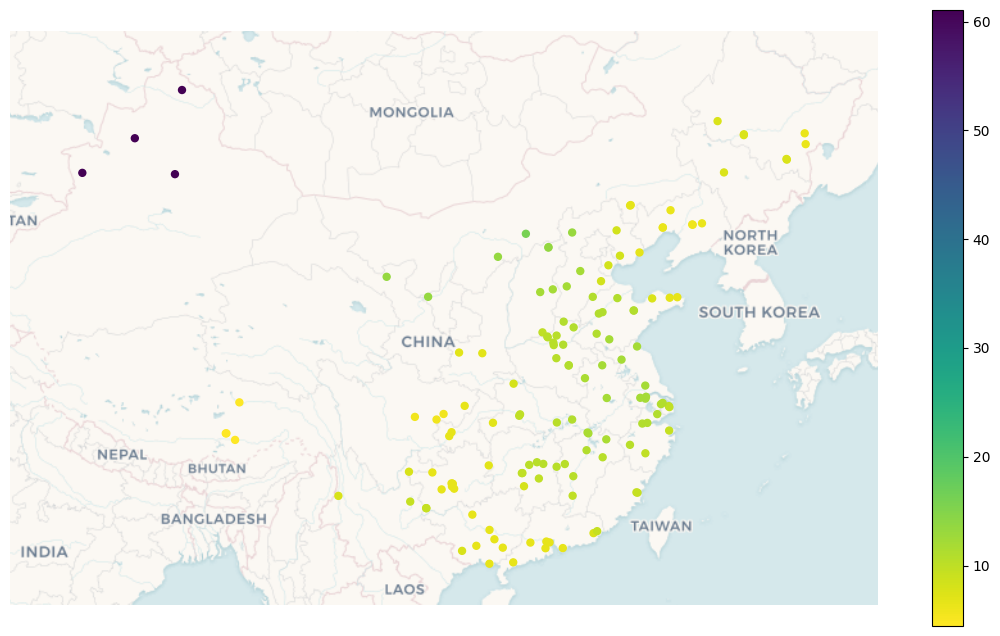

In [ ]:
results_geo = result.to_gpd()
utm = gcrs.WebMercator()

ax = gplt.webmap(results_geo, projection=utm, figsize=(14, 8), provider=cx.providers.CartoDB.Voyager)

gplt.pointplot(results_geo, hue='geo_uncertainty', cmap='viridis_r', legend=True, ax=ax)

np.float64(0.9366197183098591)

# LSCP

In [ ]:
!pip install quantile_forest mapclassify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 17.6 MB/s eta 0:00:00


In [ ]:
!pip install mapclassify


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import LSCP
from matplotlib import rcParams

# 设置PDF字体为TrueType，便于Illustrator识别
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

def interval_score(y_true, lower, upper, alpha=0.1, epsilon=1e-6):
    width = np.maximum(upper - lower, epsilon)
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    score = width + (2 / alpha) * (below + above)
    score = np.where(np.isnan(score), 0.0, score)
    return score

def k_grid_sweep_lscp(
    k_list,
    model_spatial,
    X_val,
    X_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    alpha=0.1,
    coverage_threshold=0.9,
    save_path='k_sweep_plot.pdf'  # 新增参数：保存路径
):
    coverage_list = []
    uncertainty_list = []
    interval_score_list = []

    for k in k_list:
        model = LSCP.LSCP(
            predict_f=model_spatial.predict,
            miscoverage_level=alpha,
            k=k,
            coord_calib=loc_val.values,
            coord_test=loc_test.values,
            x_calib=X_val,
            y_calib=y_val,
            x_test=X_test,
            y_test=y_test
        )

        result = model.analyze()
        coverage_list.append(result.coverage_probability)

        unc = np.array(result.geo_uncertainty / 2)  ## LSCP的本身的输出是整个的interval，而geocp是一半。需要对齐
        unc = unc[~np.isnan(unc)]
        uncertainty_list.append(np.mean(unc) if len(unc) > 0 else np.nan)

        lower = np.array(result.lower_bound)
        upper = np.array(result.upper_bound)
        y_true = np.array(y_test)

        score = interval_score(y_true, lower, upper, alpha=alpha)
        score = score[~np.isnan(score)]
        interval_score_list.append(np.mean(score) if len(score) > 0 else np.nan)

    # 找出最优 k
    mask = np.array(coverage_list) >= coverage_threshold
    masked_score = np.where(mask, interval_score_list, np.inf)
    best_idx = np.argmin(masked_score)
    best_k = k_list[best_idx]

    # 可视化
    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.plot(k_list, coverage_list, 'b-', label='Coverage')
    ax1.set_ylabel('Coverage', color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    ax2 = ax1.twinx()
    ax2.plot(k_list, uncertainty_list, 'r-', label='Mean Uncertainty')
    ax2.set_ylabel('Mean Uncertainty', color='r')
    ax2.tick_params(axis='y', labelcolor='r')

    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('axes', 1.1))
    ax3.plot(k_list, interval_score_list, 'g--', label='Interval Score', alpha=0.6)
    ax3.set_ylabel('Interval Score', color='g')
    ax3.tick_params(axis='y', labelcolor='g')

    ax1.axvline(x=best_k, color='gray', linestyle='--', alpha=0.5)
    ax1.text(best_k, coverage_list[best_idx], f'Best k={best_k}', color='gray')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper right')

    ax1.set_xlabel('k (Number of Neighbors)')
    plt.title('Coverage, Uncertainty, and Interval Score vs. k')
    plt.grid(True)
    plt.tight_layout()

    # 保存为 PDF
    plt.savefig(save_path, format='pdf')
    plt.close()

    print(f"Best k (Coverage ≥ {coverage_threshold}):")
    print(f"  k               = {best_k}")
    print(f"  Coverage        = {coverage_list[best_idx]:.3f}")
    print(f"  Interval Score  = {interval_score_list[best_idx]:.3f}")
    print(f"  Mean Interval   = {uncertainty_list[best_idx]:.3f}")

    return coverage_list, uncertainty_list, interval_score_list


In [ ]:
k_grid_sweep_lscp(
    k_list=[5, 8, 10, 15, 20],
    model_spatial=model_spatial,
    X_val=X_spatial_val,
    X_test=X_spatial_test,
    y_val=y_val,
    y_test=y_test,
    loc_val=loc_val,
    loc_test=loc_test,
    alpha=0.1,
    coverage_threshold=0.9,
    save_path='/content/drive/MyDrive/Research//0_GeoCP_with_geosimilarity//lscp.pdf'
)


🚀 Start optimizing Beta for 142 points...


Optimizing Beta (serial):  70%|███████   | 100/142 [02:26<01:06,  1.58s/it]

Progress: 100/142 | Speed: 0.68 pts/s | ETA: 1.03 min


Optimizing Beta (serial): 100%|██████████| 142/142 [03:23<00:00,  1.43s/it]


Progress: 142/142 | Speed: 0.70 pts/s | ETA: 0.00 min
✅ Beta optimization completed in 3.39 minutes.
🚀 Start predicting bounds for 142 points...


...

Progress: 100/142 | Speed: 32.14 pts/s | ETA: 0.02 min


Predicting Bounds (serial): 100%|██████████| 142/142 [00:04<00:00, 32.16it/s]


Progress: 142/142 | Speed: 32.15 pts/s | ETA: 0.00 min
✅ Prediction completed in 0.07 minutes.


Best k (Coverage ≥ 0.9):
  k               = 20
  Coverage        = 0.915
  Interval Score  = 24.240
  Mean Interval   = 9.890


([np.float64(0.8802816901408451),
  np.float64(0.9084507042253521),
  np.float64(0.9014084507042254),
  np.float64(0.9154929577464789),
  np.float64(0.9154929577464789)],
 [np.float64(9.16968185547459),
  np.float64(9.940610395166003),
  np.float64(9.84983309229754),
  np.float64(10.222089995120596),
  np.float64(9.889613009548269)],
 [np.float64(26.192067977048325),
  np.float64(24.31471321206255),
  np.float64(24.32205532498401),
  np.float64(25.532234354028805),
  np.float64(24.239776606923233)])

# GeoSIMCP——测试

In [ ]:
## GeoCP
from GeoSIMCP import GeoSIMConformalSpatialRegression

#X_spatial_val = X_spatial_val.astype(float)
#X_spatial_test = X_spatial_test.astype(float)


geosimcp = GeoSIMConformalSpatialRegression(
    predict_f=model_spatial.predict,            # 原模型，含地理特征
    miscoverage_level=0.1,
    bandwidth=0.15,
    coord_calib=loc_val.values,
    coord_test=loc_test.values,
    X_calib=X_spatial_val,                          # 包含经纬度特征
    y_calib=y_val,
    X_test=X_spatial_test,                          # 包含经纬度特征
    y_test=y_test,
    X_calib_weight=X_aspatial_val,              # 💡 纯特征向量，不含经纬度
    X_test_weight=X_aspatial_test,
    lambda_weight=0
)

results_geosimcp = geosimcp.analyze()
print("Coverage:", results_geosimcp.coverage_probability)
print("Uncertainty:", results_geosimcp.uncertainty)


Coverage: 0.6056338028169014
Uncertainty: 6.258570475206101


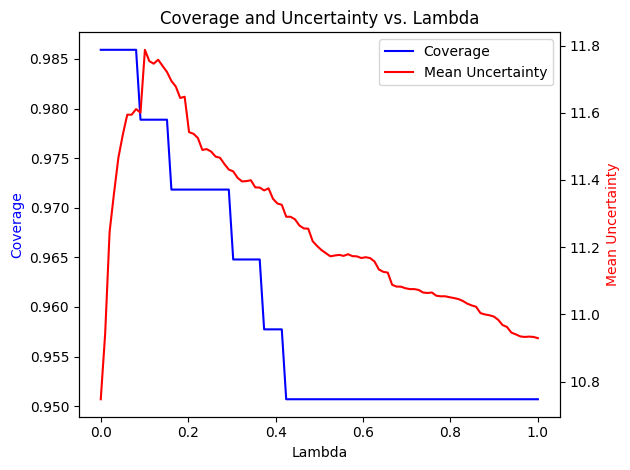

In [ ]:
lambda_list = np.linspace(0, 1, 100)
coverage_list = []
uncertainty_list = []

for lam in lambda_list:
    geosimcp = GeoSIMConformalSpatialRegression(
      predict_f=model_spatial.predict,            # 原模型，含地理特征
      miscoverage_level=0.1,
      bandwidth=3,
      coord_calib=loc_val.values,
      coord_test=loc_test.values,
      X_calib=X_spatial_val,                          # 包含经纬度特征
      y_calib=y_val,
      X_test=X_spatial_test,                          # 包含经纬度特征
      y_test=y_test,
      X_calib_weight=X_aspatial_val,              # 💡 纯特征向量，不含经纬度
      X_test_weight=X_aspatial_test,
      lambda_weight=lam
  )
    result = geosimcp.analyze()
    coverage_list.append(result.coverage_probability)
    uncertainty_list.append(result.uncertainty)


fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.plot(lambda_list, coverage_list, 'b-', label='Coverage')
ax2.plot(lambda_list, uncertainty_list, 'r-', label='Mean Uncertainty')

ax1.set_ylabel('Coverage', color='b')
ax2.set_ylabel('Mean Uncertainty', color='r')
ax1.set_xlabel('Lambda')

# 合并两个 y 轴的图例
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

plt.title('Coverage and Uncertainty vs. Lambda')
plt.tight_layout()
plt.show()



In [ ]:
X_spatial_val

,dem,sp,tp,blh,r,aod_sat,ndvi,lon,lat
354,211,97037.335938,0.002930,122.335640,74.622887,0.821065,2210,106.513000,29.389000
554,679,91500.070312,0.001168,141.428116,64.168602,0.451809,3066,113.592200,37.856100
439,-5,100785.515625,0.000588,306.366364,55.012974,0.591551,2993,122.215000,40.651100
1030,51,100346.500000,0.000649,259.619354,57.501186,0.722748,2779,115.062800,35.767200
1323,4,101054.234375,0.004096,291.782074,84.106270,0.590020,2462,121.614722,29.901667
...,...,...,...,...,...,...,...,...,...
261,112,99591.101562,0.000955,246.711365,59.567299,0.759752,3422,113.564000,34.802000
427,1066,88599.656250,0.000995,191.095566,30.531921,0.549902,1652,109.810400,40.657500
977,135,96414.437500,0.007347,128.152283,89.964439,0.501047,5843,119.500100,26.694600
904,82,99562.343750,0.000681,179.692978,58.202686,0.383055,1946,130.271900,46.802500


### interval score

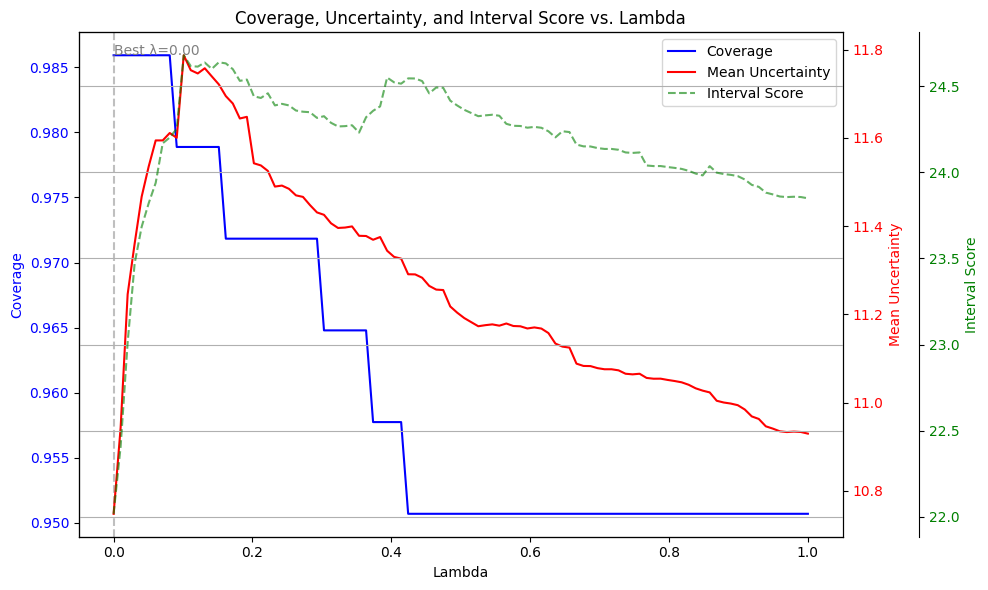

In [ ]:
# 1. 自定义函数
def interval_score(y_true, lower, upper, alpha=0.1):
    width = upper - lower
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    return width + (2 / alpha) * (below + above)


# 2. 主循环中加入 interval_score 评估
lambda_list = np.linspace(0, 1, 100)
coverage_list = []
uncertainty_list = []
interval_score_list = []

alpha = 0.1

for lam in lambda_list:
    geosimcp = GeoSIMConformalSpatialRegression(
        predict_f=model_spatial.predict,
        miscoverage_level=alpha,
        bandwidth=3,
        coord_calib=loc_val.values,
        coord_test=loc_test.values,
        X_calib=X_spatial_val,
        y_calib=y_val,
        X_test=X_spatial_test,
        y_test=y_test,
        X_calib_weight=X_aspatial_val,
        X_test_weight=X_aspatial_test,
        lambda_weight=lam
    )

    result = geosimcp.analyze()

    coverage_list.append(result.coverage_probability)
    uncertainty_list.append(result.uncertainty)

    lower = np.array(result.lower_bound)
    upper = np.array(result.upper_bound)
    y_true = np.array(y_test)

    score = interval_score(y_true, lower, upper, alpha=alpha)
    interval_score_list.append(np.mean(score))




import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# Coverage - 蓝色
ax1.plot(lambda_list, coverage_list, 'b-', label='Coverage')
ax1.set_ylabel('Coverage', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Uncertainty - 红色
ax2 = ax1.twinx()
ax2.plot(lambda_list, uncertainty_list, 'r-', label='Mean Uncertainty')
ax2.set_ylabel('Mean Uncertainty', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Interval Score - 绿色虚线
ax3 = ax1.twinx()
ax3.spines['right'].set_position(("axes", 1.1))
ax3.plot(lambda_list, interval_score_list, 'g--', label='Interval Score', alpha=0.6)
ax3.set_ylabel('Interval Score', color='g')
ax3.tick_params(axis='y', labelcolor='g')

# 标注最优点（最小 interval score）
best_idx = np.argmin(interval_score_list)
best_lambda = lambda_list[best_idx]
ax1.axvline(x=best_lambda, color='gray', linestyle='--', alpha=0.5)
ax1.text(best_lambda, coverage_list[best_idx], f'Best λ={best_lambda:.2f}', color='gray')

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper right')

ax1.set_xlabel('Lambda')
plt.title('Coverage, Uncertainty, and Interval Score vs. Lambda')
plt.grid(True)
plt.tight_layout()
plt.show()


### Optimize Bandwidth

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def interval_score(y_true, lower, upper, alpha=0.1):
    width = upper - lower
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    return width + (2 / alpha) * (below + above)


def bandwidth_sweep(
    bandwidth_list,
    model_spatial,
    X_spatial_val,
    X_spatial_test,
    X_aspatial_val,
    X_aspatial_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    alpha=0.1,
    lambda_weight=0.5
):
    coverage_list = []
    uncertainty_list = []
    interval_score_list = []

    for bw in bandwidth_list:
        model = GeoSIMConformalSpatialRegression(
            predict_f=model_spatial.predict,
            miscoverage_level=alpha,
            bandwidth=bw,
            coord_calib=loc_val.values,
            coord_test=loc_test.values,
            X_calib=X_spatial_val,
            y_calib=y_val,
            X_test=X_spatial_test,
            y_test=y_test,
            X_calib_weight=X_aspatial_val,
            X_test_weight=X_aspatial_test,
            lambda_weight=lambda_weight
        )

        result = model.analyze()

        coverage_list.append(result.coverage_probability)
        uncertainty_list.append(result.uncertainty)

        lower = np.array(result.lower_bound)
        upper = np.array(result.upper_bound)
        y_true = np.array(y_test)

        score = interval_score(y_true, lower, upper, alpha=alpha)
        interval_score_list.append(np.mean(score))

    # 可视化
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.plot(bandwidth_list, coverage_list, 'b-', label='Coverage')
    ax1.set_ylabel('Coverage', color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    ax2 = ax1.twinx()
    ax2.plot(bandwidth_list, uncertainty_list, 'r-', label='Mean Uncertainty')
    ax2.set_ylabel('Mean Uncertainty', color='r')
    ax2.tick_params(axis='y', labelcolor='r')

    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('axes', 1.1))
    ax3.plot(bandwidth_list, interval_score_list, 'g--', label='Interval Score', alpha=0.6)
    ax3.set_ylabel('Interval Score', color='g')
    ax3.tick_params(axis='y', labelcolor='g')

    best_idx = np.argmin(interval_score_list)
    best_bw = bandwidth_list[best_idx]
    ax1.axvline(x=best_bw, color='gray', linestyle='--', alpha=0.5)
    ax1.text(best_bw, coverage_list[best_idx], f'Best bw={best_bw:.2f}', color='gray')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper right')

    ax1.set_xlabel('Bandwidth')
    plt.title('Coverage, Uncertainty, and Interval Score vs. Bandwidth')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


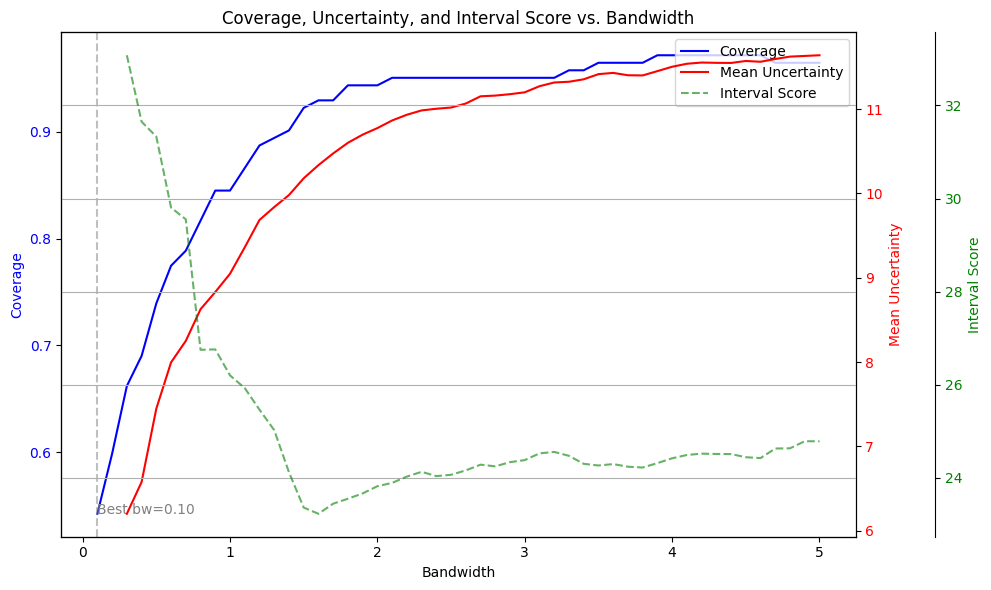

In [ ]:
bandwidth_list = np.linspace(0.1, 5.0, 50)

bandwidth_sweep(
    bandwidth_list=bandwidth_list,
    model_spatial=model_spatial,
    X_spatial_val=X_spatial_val,
    X_spatial_test=X_spatial_test,
    X_aspatial_val=X_aspatial_val,
    X_aspatial_test=X_aspatial_test,
    y_val=y_val,
    y_test=y_test,
    loc_val=loc_val,
    loc_test=loc_test,
    alpha=0.1,
    lambda_weight=0.5  # 可以固定一个 lambda
)


# GeoSIMCP自动选最优

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from GeoSIMCP import GeoSIMConformalSpatialRegression

# 矢量字体设置（更通用，避免 Arial/Helvetica 缺失警告）
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype']  = 42
matplotlib.rcParams['font.family']  = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']

def interval_score(y_true, lower, upper, alpha=0.1, epsilon=1e-6):
    """稳健版：避免负宽度/NaN 传播"""
    y_true = np.asarray(y_true, dtype=float)
    lower  = np.asarray(lower, dtype=float)
    upper  = np.asarray(upper, dtype=float)

    width = np.maximum(upper - lower, epsilon)
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    score = width + (2.0 / alpha) * (below + above)
    return np.where(np.isnan(score), 0.0, score)

def _mean_uncertainty_from_result(result):
    """兼容不同实现：优先用 result.uncertainty（标量），否则对 geo_uncertainty 取均值"""
    if hasattr(result, "uncertainty") and result.uncertainty is not None:
        try:
            return float(result.uncertainty)
        except Exception:
            pass
    if hasattr(result, "geo_uncertainty") and result.geo_uncertainty is not None:
        arr = np.asarray(result.geo_uncertainty, dtype=float)
        arr = arr[~np.isnan(arr)]
        return float(np.mean(arr)) if arr.size > 0 else np.nan
    return np.nan

def select_best_lambda_bandwidth(coverage_grid, score_grid, lambda_list, bandwidth_list, threshold=0.9):
    """先在覆盖率达标的网格里选 interval score 最小；若都不达标，回退到全局最小 score；如仍无效，选覆盖率最大。"""
    cov = np.asarray(coverage_grid, dtype=float)
    sco = np.asarray(score_grid, dtype=float)

    mask = cov >= threshold
    masked = np.where(mask, sco, np.inf)

    if np.isfinite(masked).any():
        idx = np.unravel_index(np.nanargmin(masked), masked.shape)
    else:
        # 回退1：全局最小 interval score（忽略 NaN/inf）
        valid = np.isfinite(sco)
        if valid.any():
            idx = np.unravel_index(np.nanargmin(np.where(valid, sco, np.inf)), sco.shape)
        else:
            # 回退2：覆盖率最大
            idx = np.unravel_index(np.nanargmax(cov), cov.shape)

    best_bw     = bandwidth_list[idx[0]]
    best_lambda = lambda_list[idx[1]]
    best_score  = sco[idx]
    return best_lambda, best_bw, best_score, idx

def bandwidth_lambda_grid_sweep(
    bandwidth_list,
    lambda_list,
    model_spatial,
    X_spatial_val,
    X_spatial_test,
    X_aspatial_val,
    X_aspatial_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    alpha=0.1,
    coverage_threshold=0.9,
    pdf_path="grid_sweep_results.pdf"
):
    coverage_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    uncertainty_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    interval_score_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    results_grid = [[None for _ in lambda_list] for __ in bandwidth_list]  # 新增存储

    for i, bw in enumerate(bandwidth_list):
        for j, lam in enumerate(lambda_list):
            model = GeoSIMConformalSpatialRegression(
                predict_f=model_spatial.predict,
                miscoverage_level=alpha,
                bandwidth=bw,
                coord_calib=loc_val.values,
                coord_test=loc_test.values,
                X_calib=X_spatial_val,
                y_calib=y_val,
                X_test=X_spatial_test,
                y_test=y_test,
                X_calib_weight=X_aspatial_val,
                X_test_weight=X_aspatial_test,
                lambda_weight=lam
            )

            result = model.analyze()
            results_grid[i][j] = result  # 存储每个 result

            coverage_grid[i, j] = result.coverage_probability
            uncertainty_grid[i, j] = result.uncertainty

            lower = np.array(result.lower_bound)
            upper = np.array(result.upper_bound)
            y_true = np.array(y_test)

            score = interval_score(y_true, lower, upper, alpha=alpha)
            interval_score_grid[i, j] = np.mean(score)

    # 选最优参数
    best_lambda, best_bw, best_score, idx = select_best_lambda_bandwidth(
        coverage_grid, interval_score_grid, lambda_list, bandwidth_list, threshold=coverage_threshold
    )
    best_coverage = coverage_grid[idx]
    best_uncertainty = uncertainty_grid[idx]
    best_result = results_grid[idx[0]][idx[1]]  # 取出最优 result

    # 可视化部分（保持不变）...
    # ------------------------------
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    im1 = axs[0].imshow(coverage_grid, origin='lower', aspect='auto', cmap='YlGnBu',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[0].set_title('Coverage'); axs[0].set_xlabel('Lambda'); axs[0].set_ylabel('Bandwidth')
    fig.colorbar(im1, ax=axs[0])

    im2 = axs[1].imshow(uncertainty_grid, origin='lower', aspect='auto', cmap='YlOrBr',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[1].set_title('Mean Uncertainty'); axs[1].set_xlabel('Lambda'); axs[1].set_ylabel('Bandwidth')
    fig.colorbar(im2, ax=axs[1])

    masked_score_grid = np.where(coverage_grid >= coverage_threshold, interval_score_grid, np.nan)
    im3 = axs[2].imshow(masked_score_grid, origin='lower', aspect='auto', cmap='BuGn',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[2].set_title(f'Interval Score (coverage ≥ {coverage_threshold:.2f})')
    axs[2].set_xlabel('Lambda'); axs[2].set_ylabel('Bandwidth')
    fig.colorbar(im3, ax=axs[2])

    axs[2].scatter([best_lambda], [best_bw], color='black', label='Best (λ, bw)', marker='x')
    axs[2].legend()
    plt.tight_layout(); plt.savefig(pdf_path, format='pdf'); plt.close()
    # ------------------------------

    print(f"Best parameters (coverage ≥ {coverage_threshold}):")
    print(f"  Coverage        = {best_coverage:.3f}")
    print(f"  Lambda          = {best_lambda:.3f}")
    print(f"  Bandwidth       = {best_bw:.3f}")
    print(f"  Interval Score  = {best_score:.3f}")
    print(f"  Mean Interval   = {best_uncertainty:.3f}")

    # ✅ 在原来三个 grid 基础上额外返回 best_result
    return best_result, coverage_grid, uncertainty_grid, interval_score_grid



In [ ]:
%%time
best_result,coverage_grid, uncertainty_grid, interval_score_grid = bandwidth_lambda_grid_sweep(
    bandwidth_list=np.linspace(0.1, 5.0, 20),
    lambda_list=np.linspace(0, 1.0, 20),
    model_spatial=model_spatial,
    X_spatial_val=X_spatial_val,
    X_spatial_test=X_spatial_test,
    X_aspatial_val=X_aspatial_val,
    X_aspatial_test=X_aspatial_test,
    y_val=y_val,
    y_test=y_test,
    loc_val=loc_val,
    loc_test=loc_test,
    alpha=0.1,
    coverage_threshold=0.9,
    pdf_path="PM2.5_GeoSIMCP.pdf"

)


Best parameters (coverage ≥ 0.9):
  Coverage        = 0.965
  Lambda          = 0.000
  Bandwidth       = 2.679
  Interval Score  = 21.448
  Mean Interval   = 9.638
CPU times: user 43 s, sys: 53.5 ms, total: 43.1 s
Wall time: 43.7 s


<GeoAxes: >

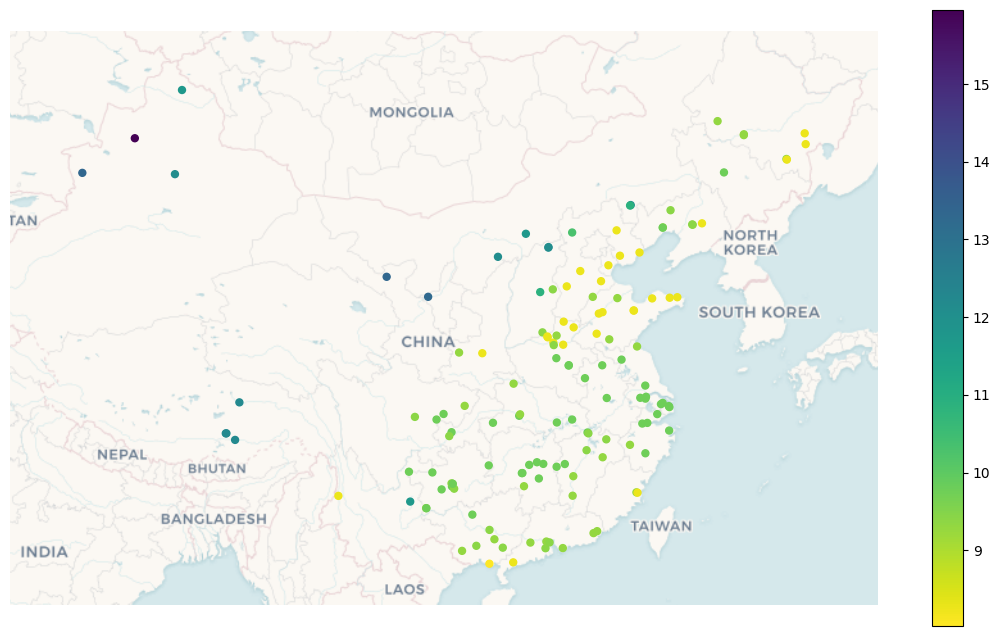

In [ ]:
results_geo = best_result.to_gpd()
utm = gcrs.WebMercator()

ax = gplt.webmap(results_geo, projection=utm, figsize=(14, 8), provider=cx.providers.CartoDB.Voyager)

gplt.pointplot(results_geo, hue='geo_uncertainty', cmap='viridis_r', legend=True, ax=ax)

/usr/local/lib/python3.12/dist-packages/geoplot/geoplot.py:1659: UserWarning: "webmap" is only compatible with the "WebMercator" projection, but the input projection is unspecified. Reprojecting the data to "WebMercator" automatically. To suppress this warning, set "projection=gcrs.WebMercator()" explicitly.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/geoplot/geoplot.py:248: UserWarning: Please specify "legend_var" explicitly when both "hue" and "scale" are specified. Defaulting to "legend_var='hue'".
  warnings.warn(


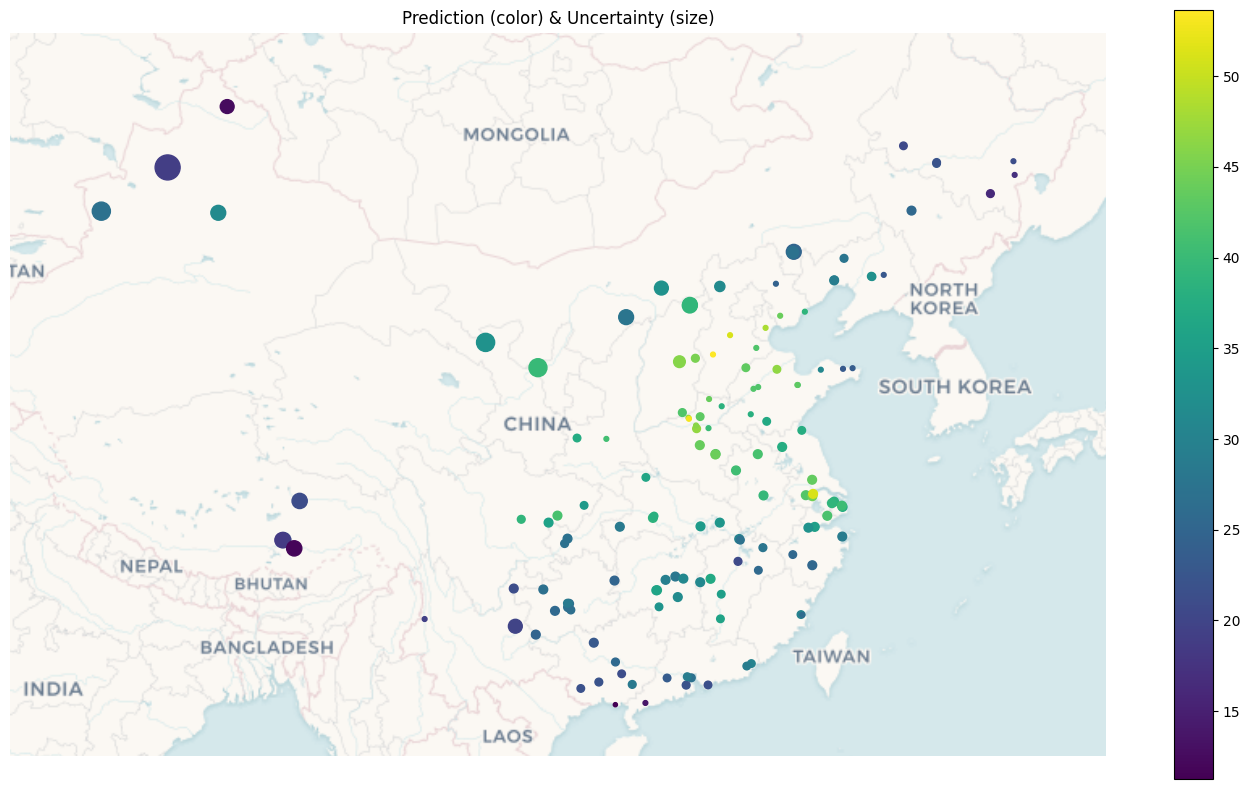

In [ ]:
import geoplot as gplt
import contextily as cx
import matplotlib.pyplot as plt
import numpy as np

size_col = "interval_width"   # 或 "geo_uncertainty"

ax = gplt.webmap(results_geo, figsize=(14, 8),
                 provider=cx.providers.CartoDB.Voyager)

gplt.pointplot(
    results_geo, ax=ax,
    hue="pred", cmap="viridis", legend=True,
    scale=size_col, limits=(3, 18)
)

plt.title("Prediction (color) & Uncertainty (size)")
plt.tight_layout()


In [ ]:
results_geo = best_result.to_gpd()
utm = gcrs.WebMercator()

ax = gplt.webmap(results_geo, projection=utm, figsize=(14, 8), provider=cx.providers.CartoDB.Voyager)

gplt.pointplot(results_geo, hue='geo_uncertainty', cmap='viridis_r', legend=True, ax=ax)

results_geo.to_file(
    "GeoCP_results.shp",
    driver="ESRI Shapefile",
    encoding="utf-8"   # 如果有中文字段名，保证不乱码
)


/tmp/ipython-input-1080902626.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  results_geo.to_file(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'geo_uncertainty' to 'geo_uncert'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'upper_bound' to 'upper_boun'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lower_bound' to 'lower_boun'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'interval_width' to 'interval_w'
  ogr_write(


# GeoSIMCP——zhao2024 自动选最优

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib
# from GeoSIMCPzhao import GeoSIMCPzhao

# # 设置 PDF 兼容字体
# matplotlib.rcParams['pdf.fonttype'] = 42  # 字体向量化，确保 Illustrator 可识别
# matplotlib.rcParams['ps.fonttype'] = 42
# plt.rcParams['font.family'] = 'Arial'     # Helvetica/Arial 一般最安全

# def interval_score(y_true, lower, upper, alpha=0.1, epsilon=1e-6):
#     width = np.maximum(upper - lower, epsilon)
#     below = (lower - y_true) * (y_true < lower)
#     above = (y_true - upper) * (y_true > upper)
#     score = width + (2 / alpha) * (below + above)
#     score = np.where(np.isnan(score), 0.0, score)
#     return score

# def select_best_lambda_bandwidth(coverage_grid, score_grid, lambda_list, bandwidth_list, threshold=0.9):
#     mask = coverage_grid >= threshold
#     masked_score = np.where(mask, score_grid, np.inf)
#     idx = np.unravel_index(np.argmin(masked_score), masked_score.shape)
#     best_lambda = lambda_list[idx[1]]
#     best_bandwidth = bandwidth_list[idx[0]]
#     return best_lambda, best_bandwidth, masked_score[idx], idx

# def bandwidth_lambda_grid_sweep(
#     bandwidth_list,
#     lambda_list,
#     model_spatial,
#     X_spatial_val,
#     X_spatial_test,
#     X_aspatial_val,
#     X_aspatial_test,
#     y_val,
#     y_test,
#     loc_val,
#     loc_test,
#     alpha=0.1,
#     coverage_threshold=0.9,
#     output_pdf_path='grid_sweep_results.pdf'  # 新增参数：输出PDF路径
# ):
#     coverage_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
#     uncertainty_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
#     interval_score_grid = np.zeros((len(bandwidth_list), len(lambda_list)))

#     for i, bw in enumerate(bandwidth_list):
#         for j, lam in enumerate(lambda_list):
#             model = GeoSIMCPzhao(
#                 predict_f=model_spatial.predict,
#                 miscoverage_level=alpha,
#                 bandwidth=bw,
#                 coord_calib=loc_val.values,
#                 coord_test=loc_test.values,
#                 X_calib=X_spatial_val,
#                 y_calib=y_val,
#                 X_test=X_spatial_test,
#                 y_test=y_test,
#                 X_calib_weight=X_aspatial_val,
#                 X_test_weight=X_aspatial_test,
#                 lambda_weight=lam
#             )

#             result = model.analyze()

#             coverage_grid[i, j] = result.coverage_probability
#             if result.geo_uncertainty is not None:
#                 valid_uncertainty = np.array(result.geo_uncertainty)
#                 valid_uncertainty = valid_uncertainty[~np.isnan(valid_uncertainty)]
#                 uncertainty_grid[i, j] = np.mean(valid_uncertainty) if len(valid_uncertainty) > 0 else np.nan
#             else:
#                 uncertainty_grid[i, j] = np.nan

#             lower = np.array(result.lower_bound)
#             upper = np.array(result.upper_bound)
#             y_true = np.array(y_test)

#             score = interval_score(y_true, lower, upper, alpha=alpha)
#             score_filtered = score[~np.isnan(score)]
#             interval_score_grid[i, j] = np.mean(score_filtered) if len(score_filtered) > 0 else np.nan

#             if np.isnan(interval_score_grid[i, j]):
#                 print(f"[Warning] NaN interval score at λ={lam:.3f}, bw={bw:.3f}")

#     best_lambda, best_bw, best_score, idx = select_best_lambda_bandwidth(
#         coverage_grid, interval_score_grid, lambda_list, bandwidth_list, threshold=coverage_threshold
#     )
#     best_coverage = coverage_grid[idx]
#     best_uncertainty = uncertainty_grid[idx]

#     fig, axs = plt.subplots(1, 3, figsize=(18, 5))

#     im1 = axs[0].imshow(coverage_grid, origin='lower', aspect='auto', cmap='YlGnBu',
#                         extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
#     axs[0].set_title('Coverage')
#     axs[0].set_xlabel('Lambda')
#     axs[0].set_ylabel('Bandwidth')
#     fig.colorbar(im1, ax=axs[0])

#     im2 = axs[1].imshow(uncertainty_grid, origin='lower', aspect='auto', cmap='YlOrBr',
#                         extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
#     axs[1].set_title('Mean Uncertainty')
#     axs[1].set_xlabel('Lambda')
#     axs[1].set_ylabel('Bandwidth')
#     fig.colorbar(im2, ax=axs[1])

#     masked_score_grid = np.where(coverage_grid >= coverage_threshold, interval_score_grid, np.nan)
#     im3 = axs[2].imshow(masked_score_grid, origin='lower', aspect='auto', cmap='BuGn',
#                         extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
#     axs[2].set_title(f'Interval Score (coverage ≥ {coverage_threshold:.2f})')
#     axs[2].set_xlabel('Lambda')
#     axs[2].set_ylabel('Bandwidth')
#     fig.colorbar(im3, ax=axs[2])

#     axs[2].scatter([best_lambda], [best_bw], color='black', label='Best (λ, bw)', marker='x')
#     axs[2].legend()

#     plt.tight_layout()
#     plt.savefig(output_pdf_path, format='pdf')  # 关键导出步骤
#     plt.show()

#     print(f"Best parameters (coverage ≥ {coverage_threshold}):")
#     print(f"  Coverage        = {best_coverage:.3f}")
#     print(f"  Lambda          = {best_lambda:.3f}")
#     print(f"  Bandwidth       = {best_bw:.3f}")
#     print(f"  Interval Score  = {best_score:.3f}")
#     print(f"  Mean Interval   = {best_uncertainty:.3f}")

#     return coverage_grid, uncertainty_grid, interval_score_grid


In [ ]:
def bandwidth_lambda_grid_sweep(
    bandwidth_list,
    lambda_list,
    model_spatial,
    X_spatial_val,
    X_spatial_test,
    X_aspatial_val,
    X_aspatial_test,
    y_val,
    y_test,
    loc_val,
    loc_test,
    alpha=0.1,
    coverage_threshold=0.9,
    output_pdf_path='grid_sweep_results.pdf'
):
    coverage_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    uncertainty_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    interval_score_grid = np.zeros((len(bandwidth_list), len(lambda_list)))
    results_grid = [[None for _ in lambda_list] for __ in bandwidth_list]  # 最小新增

    # 兼容 numpy / pandas 输入（避免 .values 报错）
    coord_calib = getattr(loc_val, "values", loc_val)   # 最小新增（稳健）
    coord_test  = getattr(loc_test, "values", loc_test) # 最小新增（稳健）

    for i, bw in enumerate(bandwidth_list):
        for j, lam in enumerate(lambda_list):
            model = GeoSIMCPzhao(
                predict_f=model_spatial.predict,
                miscoverage_level=alpha,
                bandwidth=bw,
                coord_calib=coord_calib,   # 使用上面的稳健变量
                coord_test=coord_test,     # 使用上面的稳健变量
                X_calib=X_spatial_val,
                y_calib=y_val,
                X_test=X_spatial_test,
                y_test=y_test,
                X_calib_weight=X_aspatial_val,
                X_test_weight=X_aspatial_test,
                lambda_weight=lam
            )

            result = model.analyze()
            results_grid[i][j] = result  # 最小新增：保存每个 result

            coverage_grid[i, j] = result.coverage_probability
            if result.geo_uncertainty is not None:
                valid_uncertainty = np.array(result.geo_uncertainty)
                valid_uncertainty = valid_uncertainty[~np.isnan(valid_uncertainty)]
                uncertainty_grid[i, j] = np.mean(valid_uncertainty) if len(valid_uncertainty) > 0 else np.nan
            else:
                uncertainty_grid[i, j] = np.nan

            lower = np.array(result.lower_bound)
            upper = np.array(result.upper_bound)
            y_true = np.array(y_test)

            score = interval_score(y_true, lower, upper, alpha=alpha)
            score_filtered = score[~np.isnan(score)]
            interval_score_grid[i, j] = np.mean(score_filtered) if len(score_filtered) > 0 else np.nan

            if np.isnan(interval_score_grid[i, j]):
                print(f"[Warning] NaN interval score at λ={lam:.3f}, bw={bw:.3f}")

    best_lambda, best_bw, best_score, idx = select_best_lambda_bandwidth(
        coverage_grid, interval_score_grid, lambda_list, bandwidth_list, threshold=coverage_threshold
    )
    best_coverage = coverage_grid[idx]
    best_uncertainty = uncertainty_grid[idx]

    # 取出最优 result，并“导出”到函数属性（不改变返回值）

    best_result = results_grid[idx[0]][idx[1]]

    bandwidth_lambda_grid_sweep.best_result = best_result
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    im1 = axs[0].imshow(coverage_grid, origin='lower', aspect='auto', cmap='YlGnBu',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[0].set_title('Coverage')
    axs[0].set_xlabel('Lambda')
    axs[0].set_ylabel('Bandwidth')
    fig.colorbar(im1, ax=axs[0])

    im2 = axs[1].imshow(uncertainty_grid, origin='lower', aspect='auto', cmap='YlOrBr',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[1].set_title('Mean Uncertainty')
    axs[1].set_xlabel('Lambda')
    axs[1].set_ylabel('Bandwidth')
    fig.colorbar(im2, ax=axs[1])

    masked_score_grid = np.where(coverage_grid >= coverage_threshold, interval_score_grid, np.nan)
    im3 = axs[2].imshow(masked_score_grid, origin='lower', aspect='auto', cmap='BuGn',
                        extent=[lambda_list[0], lambda_list[-1], bandwidth_list[0], bandwidth_list[-1]])
    axs[2].set_title(f'Interval Score (coverage ≥ {coverage_threshold:.2f})')
    axs[2].set_xlabel('Lambda')
    axs[2].set_ylabel('Bandwidth')
    fig.colorbar(im3, ax=axs[2])

    axs[2].scatter([best_lambda], [best_bw], color='black', label='Best (λ, bw)', marker='x')
    axs[2].legend()

    plt.tight_layout()
    plt.savefig(output_pdf_path, format='pdf')
    plt.show()

    print(f"Best parameters (coverage ≥ {coverage_threshold}):")
    print(f"  Coverage        = {best_coverage:.3f}")
    print(f"  Lambda          = {best_lambda:.3f}")
    print(f"  Bandwidth       = {best_bw:.3f}")
    print(f"  Interval Score  = {best_score:.3f}")
    print(f"  Mean Interval   = {best_uncertainty:.3f}")

    # 保持原有返回：不破坏你现有解包代码
    return best_result,coverage_grid, uncertainty_grid, interval_score_grid


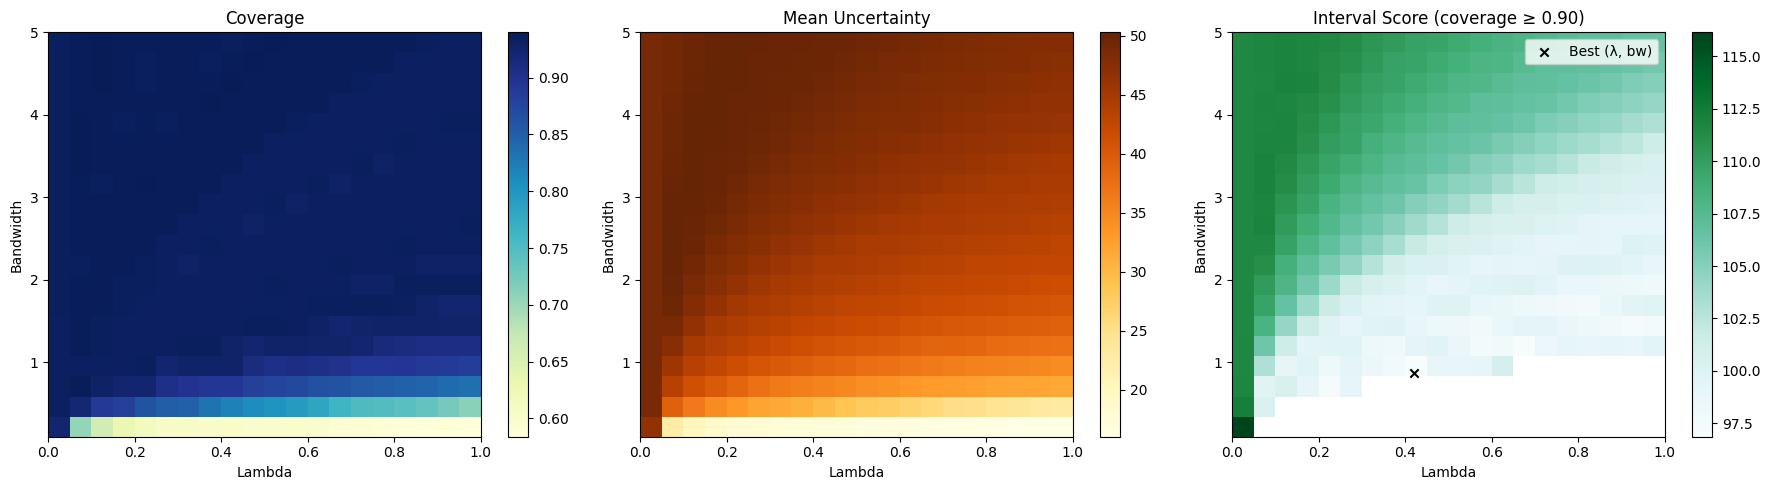

Best parameters (coverage ≥ 0.9):
  Coverage        = 0.927
  Lambda          = 0.421
  Bandwidth       = 0.874
  Interval Score  = 96.863
  Mean Interval   = 38.828
CPU times: user 1min 11s, sys: 170 ms, total: 1min 11s
Wall time: 1min 12s


In [ ]:
%%time
best_result,coverage_grid, uncertainty_grid, interval_score_grid = bandwidth_lambda_grid_sweep(
    bandwidth_list=np.linspace(0.1, 5.0, 20),
    lambda_list=np.linspace(0, 1.0, 20),
    model_spatial=model_spatial,
    X_spatial_val=X_spatial_val,
    X_spatial_test=X_spatial_test,
    X_aspatial_val=X_aspatial_val,
    X_aspatial_test=X_aspatial_test,
    y_val=y_val,
    y_test=y_test,
    loc_val=loc_val,
    loc_test=loc_test,
    alpha=0.1,
    coverage_threshold=0.9,
    output_pdf_path='PM2.5_GeoSIMCP_zhao.pdf'  # 加这一行即可导出 PDF

)

In [ ]:
best_result

<GeoAxes: >

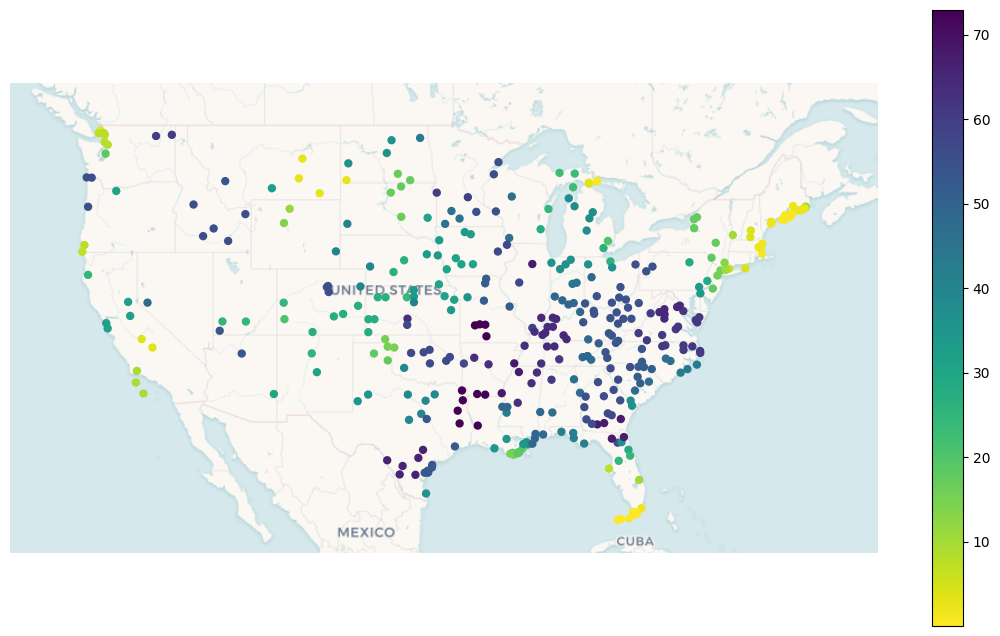

In [ ]:
results_geo = best_result.to_gpd()
utm = gcrs.WebMercator()

ax = gplt.webmap(results_geo, projection=utm, figsize=(14, 8), provider=cx.providers.CartoDB.Voyager)

gplt.pointplot(results_geo, hue='geo_uncertainty', cmap='viridis_r', legend=True, ax=ax)


In [ ]:
results_geo

,geo_uncertainty,pred,upper_bound,lower_bound,x,y,geometry
0,0.524365,78.009400,78.533765,77.485035,-68.981815,44.174017,POINT (-68.98182 44.17402)
1,6.206763,78.680441,84.887205,72.473678,-73.389046,41.067178,POINT (-73.38905 41.06718)
2,61.150326,65.935172,127.085498,4.784846,-76.992157,38.507296,POINT (-76.99216 38.5073)
3,18.472492,75.256097,93.728589,56.783604,-90.440817,29.256239,POINT (-90.44082 29.25624)
4,63.381802,6.552456,69.934258,-56.829346,-98.717409,38.030990,POINT (-98.71741 38.03099)
...,...,...,...,...,...,...,...
394,55.345515,70.696267,126.041782,15.350751,-123.979843,46.263047,POINT (-123.97984 46.26305)
395,66.080964,28.824690,94.905654,-37.256274,-97.859391,28.905719,POINT (-97.85939 28.90572)
396,26.538042,18.966907,45.504949,-7.571136,-99.819567,40.869951,POINT (-99.81957 40.86995)
397,48.863947,72.957913,121.821861,24.093966,-84.543416,35.673153,POINT (-84.54342 35.67315)


In [ ]:

results_geo.to_file(
    "GeoCP_results_USlife.shp",
    driver="ESRI Shapefile",
    encoding="utf-8"   # 如果有中文字段名，保证不乱码
)


/tmp/ipython-input-916053160.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  results_geo.to_file(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'geo_uncertainty' to 'geo_uncert'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'upper_bound' to 'upper_boun'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'lower_bound' to 'lower_boun'
  ogr_write(
